In [2]:
!pip install librosa dtw-python soundfile matplotlib numpy scipy

In [3]:
# ==========================================
# UPLOAD TWO AUDIO FILES
# ==========================================
from google.colab import files

print("Upload your 2 audio files (one .m4a and one .opus):")
uploaded = files.upload()

# Automatically get filenames
file_names = list(uploaded.keys())
if len(file_names) != 2:
    raise Exception("Please upload exactly TWO files.")

signal1_file = file_names[0]
signal2_file = file_names[1]

print("\nSignal 1 =", signal1_file)
print("Signal 2 =", signal2_file)

Upload your 2 audio files (one .m4a and one .opus):


Saving adi.m4a to adi (2).m4a
Saving sam.opus to sam (2).opus

Signal 1 = adi (2).m4a
Signal 2 = sam (2).opus


In [4]:
# ==========================================
# LOAD AUDIO FILES & CONVERT TO WAVEFORMS
# ==========================================
import librosa
import numpy as np

signal1, sr1 = librosa.load(signal1_file, sr=None)
signal2, sr2 = librosa.load(signal2_file, sr=None)

print("\nLoaded audio successfully!")
print("Signal 1 length:", len(signal1), " | Sample rate:", sr1)
print("Signal 2 length:", len(signal2), " | Sample rate:", sr2)

/tmp/ipython-input-952163111.py:7: UserWarning: PySoundFile failed. Trying audioread instead.
  signal1, sr1 = librosa.load(signal1_file, sr=None)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)



Loaded audio successfully!
Signal 1 length: 150528  | Sample rate: 48000
Signal 2 length: 49245  | Sample rate: 16000


In [5]:
# ==========================================
# NORMALIZE THE SIGNALS
# ==========================================
def normalize(sig):
    return sig / np.max(np.abs(sig))

signal1_norm = normalize(signal1)
signal2_norm = normalize(signal2)

print("\nSignals normalized.")


Signals normalized.


In [7]:
mfcc1 = librosa.feature.mfcc(y=signal1_norm, sr=sr1, n_mfcc=13)
mfcc2 = librosa.feature.mfcc(y=signal2_norm, sr=sr2, n_mfcc=13)

# Transpose so frames become rows
mfcc1 = mfcc1.T
mfcc2 = mfcc2.T

print("MFCC Shapes:", mfcc1.shape, mfcc2.shape)

MFCC Shapes: (295, 13) (97, 13)


In [9]:
# ==========================================
# APPLY DYNAMIC TIME WARPING
# ==========================================
from dtw import dtw
from numpy.linalg import norm

print("\nRunning DTW on MFCC features...")
dtw_result = dtw(mfcc1, mfcc2, dist_method='euclidean')

dtw_distance = dtw_result.distance
path_x = dtw_result.index1
path_y = dtw_result.index2

print("\nDTW Distance =", dtw_distance)
print("Alignment path length =", len(path_x))


Running DTW on MFCC features...

DTW Distance = 32150.124845628972
Alignment path length = 371


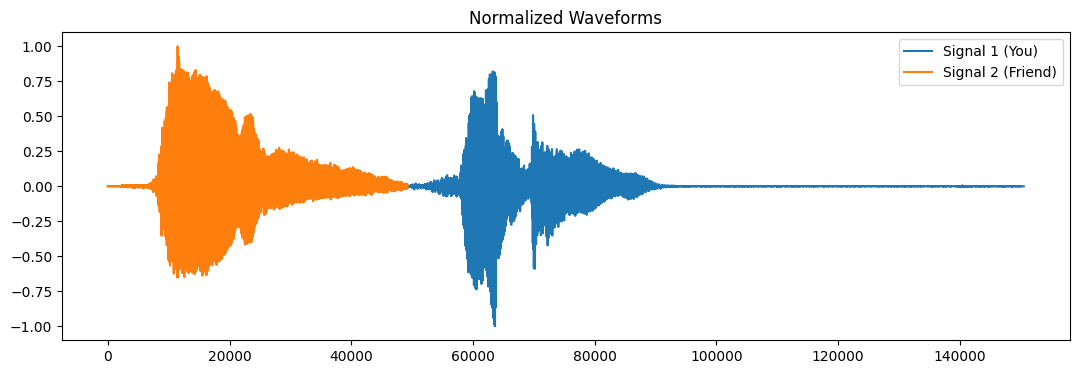

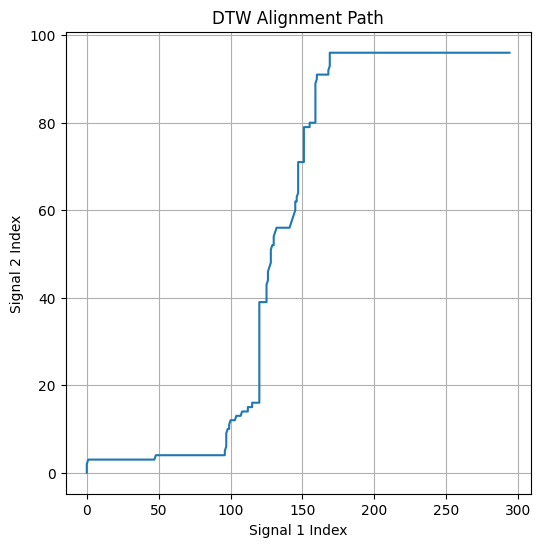

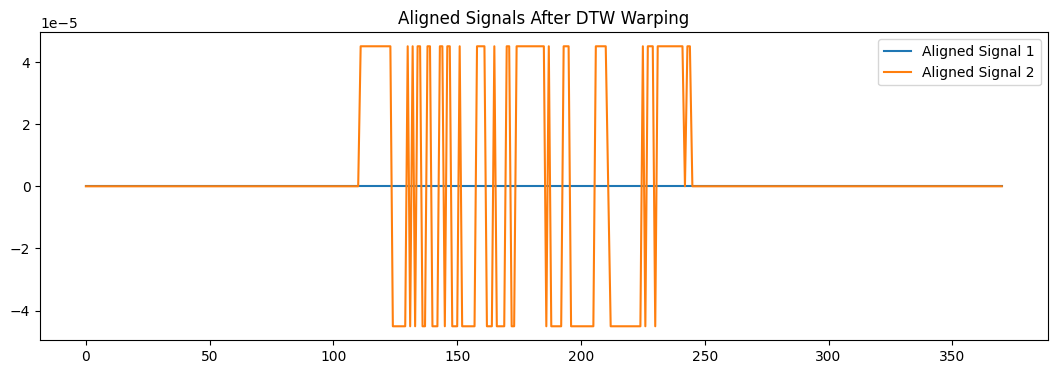

In [10]:
import matplotlib.pyplot as plt

# ---- Plot the raw waveforms ----
plt.figure(figsize=(13,4))
plt.plot(signal1_norm, label="Signal 1 (You)")
plt.plot(signal2_norm, label="Signal 2 (Friend)")
plt.title("Normalized Waveforms")
plt.legend()
plt.show()

# ---- Plot DTW alignment path ----
plt.figure(figsize=(6,6))
plt.plot(path_x, path_y)
plt.xlabel("Signal 1 Index")
plt.ylabel("Signal 2 Index")
plt.title("DTW Alignment Path")
plt.grid()
plt.show()

# ---- Plot aligned signals ----
aligned_1 = signal1_norm[path_x]
aligned_2 = signal2_norm[path_y]

plt.figure(figsize=(13,4))
plt.plot(aligned_1, label="Aligned Signal 1")
plt.plot(aligned_2, label="Aligned Signal 2")
plt.title("Aligned Signals After DTW Warping")
plt.legend()
plt.show()


In [11]:
# ==========================================
# INTERPRETATION TEXT
# ==========================================
print("\n\n================ INTERPRETATION ================\n")

print(f"Dynamic Time Warping Distance: {dtw_distance:.2f}")

if dtw_distance < 50:
    similarity = "VERY similar"
elif dtw_distance < 150:
    similarity = "moderately similar"
else:
    similarity = "quite different"

print(f"\nSimilarity assessment: The two signals are {similarity}.\n")

print("""
Interpretation:
Both recordings contain the word 'hello', but they differ in timing, amplitude,
and articulation. DTW aligns the two signals by stretching and compressing
their time axes so that matching phonetic patterns (like 'he' and 'llo')
are brought into alignment.

The alignment path shows where the two signals differ in speed.
A bending path means one speaker said part of the word slower or faster.

DTW is useful in audio analysis because it can compare signals even when they
do not line up perfectly in time. This helps match similar speech patterns
spoken at different speeds or by different speakers.
""")



================ INTERPRETATION ================

Dynamic Time Warping Distance: 32150.12

Similarity assessment: The two signals are quite different.


Interpretation:
Both recordings contain the word 'hello', but they differ in timing, amplitude,
and articulation. DTW aligns the two signals by stretching and compressing 
their time axes so that matching phonetic patterns (like 'he' and 'llo')
are brought into alignment.

The alignment path shows where the two signals differ in speed.
A bending path means one speaker said part of the word slower or faster.

DTW is useful in audio analysis because it can compare signals even when they
do not line up perfectly in time. This helps match similar speech patterns
spoken at different speeds or by different speakers.

